Algorithme KNN

In [1]:
import numpy as np                           
import pandas as pd                          
import matplotlib.pyplot as plt              
from collections import Counter                       

print("KNN - K-NEAREST NEIGHBORS ")
df = pd.read_csv('auto_mpg.csv')
# creer la variable cible binaire : 1 si mpg > median (voiture économique), 0 sinon
df['economique'] = (df['mpg'] > df['mpg'].median()).astype(int)

features = ['weight', 'horsepower']          # variables explicatives (2D pour visualisation)
X = df[features].values                      # variable explicative sous forme de matrice
y = df['economique'].values                  # variable cible : 0=non économique, 1=économique





def normaliser(X):                                        # normalisation min-max pour stabiliser les distances
    X_min = X.min(axis=0)#  valeur min de chaque colonne 
    X_max = X.max(axis=0)#  valeur max de chaque colonne
    return (X - X_min) / (X_max - X_min + 1e-8)          # eviter la division par zero




X_n = normaliser(X)                          # normaliser toutes les données





def knn_predict_scratch(X_train, y_train, X_pred, k=5):  # algorithme KNN : pour chaque point 
    predictions = []                                      # trouver les k voisins les plus proches et voter

    for x in X_pred:
        # calcul des distances euclidiennes entre x et tous les points d'entrainement
        distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))  # d = √Σ(xi - xj)²

        k_indices = np.argsort(distances)[:k]             # indices des k plus proches voisins (triés)
        k_labels  = y_train[k_indices]                    # classes des k voisins

        vote = Counter(k_labels).most_common(1)[0][0]     # classe majoritaire parmi les k voisins (vote)
        predictions.append(vote)                          # ajouter la prédiction

    return np.array(predictions)





pred_knn = knn_predict_scratch(X_n, y, X_n, k=5)  # prédire avec k=5 (memes données : entrainement = prediction)





#métriques d'évaluation                                       calcule
accuracy_knn  = np.mean(pred_knn == y)                       # ACCURACY  = nbr correct / nbr total
TP = np.sum((pred_knn == 1) & (y == 1))                      # vrais positifs
TN = np.sum((pred_knn == 0) & (y == 0))                      # vrais négatifs
FP = np.sum((pred_knn == 1) & (y == 0))                      # faux positifs
FN = np.sum((pred_knn == 0) & (y == 1))                      # faux négatifs
precision_knn = TP / (TP + FP + 1e-8)                        # PRECISION = TP / (TP + FP)
recall_knn    = TP / (TP + FN + 1e-8)                        # RECALL    = TP / (TP + FN)
f1_knn        = 2 * precision_knn * recall_knn / (precision_knn + recall_knn + 1e-8) # F1-SCORE





print(f"k = 5 voisins")
print(f"Accuracy  = {accuracy_knn:.4f}")
print(f"Precision = {precision_knn:.4f}")
print(f"Recall    = {recall_knn:.4f}")
print(f"F1-Score  = {f1_knn:.4f}")

print("_" * 80)

# tester differentes valeurs de k pour trouver le meilleur
print("Comparaison des valeurs de k :")
k_values = [1, 3, 5, 7, 9, 11, 15]                           # liste de valeurs de k à tester
acc_list = []
for k in k_values:
    pred_k = knn_predict_scratch(X_n, y, X_n, k=k)
    acc_k  = np.mean(pred_k == y)
    acc_list.append(acc_k)
    print(f"  k={k:2d}  Accuracy={acc_k:.4f}")

print("_" * 80)

print("Matrice de Confusion (k=5):")
print(f"  TP={TP}  FP={FP}")
print(f"  FN={FN}  TN={TN}")




KNN - K-NEAREST NEIGHBORS 
k = 5 voisins
Accuracy  = 0.8546
Precision = 0.8864
Recall    = 0.8083
F1-Score  = 0.8455
________________________________________________________________________________
Comparaison des valeurs de k :
  k= 1  Accuracy=1.0000
  k= 3  Accuracy=0.8827
  k= 5  Accuracy=0.8546
  k= 7  Accuracy=0.8444
  k= 9  Accuracy=0.8520
  k=11  Accuracy=0.8546
  k=15  Accuracy=0.8469
________________________________________________________________________________
Matrice de Confusion (k=5):
  TP=156  FP=20
  FN=37  TN=179


In [ ]:
GRAPHES

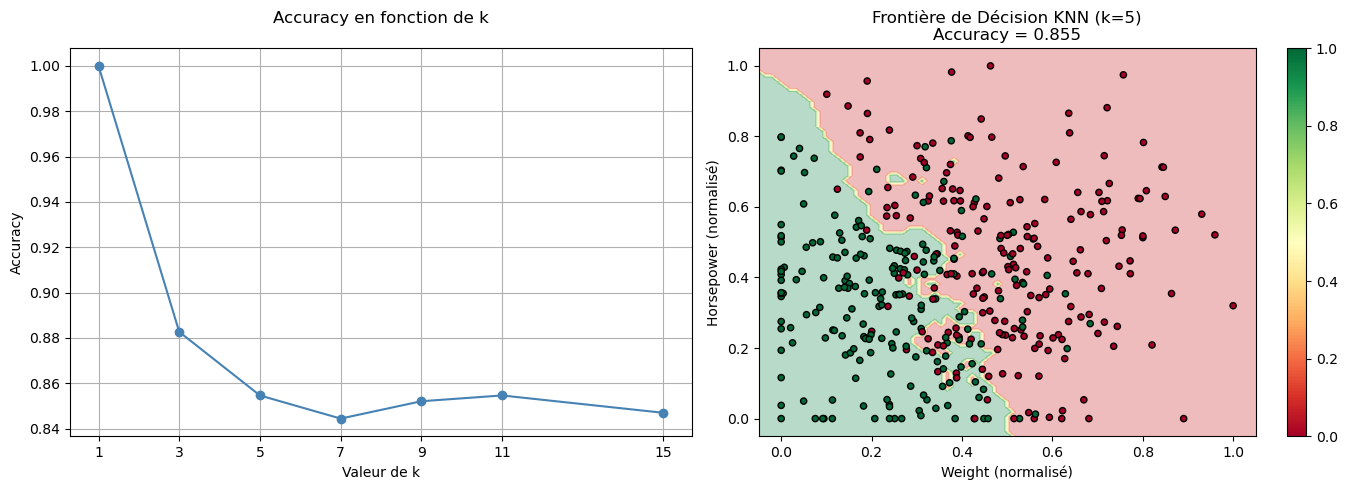

In [2]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))      

# courbe accuracy vs k
axes[0].plot(k_values, acc_list, marker='o', color='steelblue')
axes[0].set_title('Accuracy en fonction de k\n')
axes[0].set_xlabel('Valeur de k')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)
axes[0].set_xticks(k_values)




# frontière de décision (k=5)
x_min, x_max = X_n[:, 0].min() - 0.05, X_n[:, 0].max() + 0.05 
y_min, y_max = X_n[:, 1].min() - 0.05, X_n[:, 1].max() + 0.05 
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80),# résolution réduite car KNN scratch est lent sur grille dense
                     np.linspace(y_min, y_max, 80)) 
grid   = np.c_[xx.ravel(), yy.ravel()]
Z_knn  = knn_predict_scratch(X_n, y, grid, k=5).reshape(xx.shape)

axes[1].contourf(xx, yy, Z_knn, alpha=0.3, cmap='RdYlGn')
scatter = axes[1].scatter(X_n[:, 0], X_n[:, 1], c=y, cmap='RdYlGn', edgecolors='k', s=20)
axes[1].set_title(f'Frontière de Décision KNN (k=5)\nAccuracy = {accuracy_knn:.3f}')
axes[1].set_xlabel('Weight (normalisé)')
axes[1].set_ylabel('Horsepower (normalisé)')
plt.colorbar(scatter, ax=axes[1])





plt.tight_layout()                                    
plt.savefig('resultats_knn_scratch.png', dpi=150)         
plt.show()                                            